In [ ]:
import pandas as pd
from google.colab import files

In [ ]:
upload = files.upload()

Saving FakeNewsNet.csv to FakeNewsNet.csv


In [ ]:
data = pd.read_csv("FakeNewsNet.csv")

In [ ]:
data.head()

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


In [ ]:
data.tail()

,title,news_url,source_domain,tweet_num,real
23191,Pippa Middleton wedding: In case you missed it...,https://www.express.co.uk/news/royal/807049/pi...,www.express.co.uk,52,1
23192,Zayn Malik & Gigi Hadid’s Shocking Split: Why ...,hollywoodlife.com/2018/03/13/zayn-malik-gigi-h...,hollywoodlife.com,7,0
23193,Jessica Chastain Recalls the Moment Her Mother...,http://www.justjared.com/2018/01/17/jessica-ch...,www.justjared.com,26,1
23194,"Tristan Thompson Feels ""Dumped"" After Khloé Ka...",www.intouchweekly.com/posts/tristan-thompson-f...,www.intouchweekly.com,24,0
23195,Kelly Clarkson Performs a Medley of Kendrick L...,https://www.billboard.com/articles/news/bbma/8...,www.billboard.com,85,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23196 entries, 0 to 23195
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          23196 non-null  object
 1   news_url       22866 non-null  object
 2   source_domain  22866 non-null  object
 3   tweet_num      23196 non-null  int64 
 4   real           23196 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 906.2+ KB


In [ ]:
data.shape

(23196, 5)

In [ ]:
data.columns

Index(['title', 'news_url', 'source_domain', 'tweet_num', 'real'], dtype='object')

In [ ]:
data.dtypes

,0
title,object
news_url,object
source_domain,object
tweet_num,int64
real,int64


In [ ]:
missing_values_rows = data.isnull().any(axis=1)
print("Rows with  Missing Values:")
print(missing_values_rows)

Rows with  Missing Values:
0        False
1        False
2        False
3        False
4        False
         ...  
23191    False
23192    False
23193    False
23194    False
23195    False
Length: 23196, dtype: bool


In [ ]:
duplicate_rows = data[data.duplicated()]
print("Duplicated Rows:")
print(duplicate_rows)

Duplicated Rows:
                                                   title  \
1166   Brad Pitt and Jennifer Aniston's second weddin...   
3330   'Today': Ratings show replacing Matt Lauer wit...   
3355   Katie Holmes’ trials: Fighting reports about a...   
3445   Kourtney Kardashian Reportedly Pregnant With B...   
3495   'Bachelor' Alum Vienna Girardi Reveals Gender ...   
...                                                  ...   
22750  Inside Jennifer Aniston and Justin Theroux's $...   
22781  Justin Theroux Found Post-Its From Brad Pitt D...   
22797  Jennifer Lopez Is Questioning Her Future With ...   
22806  Is Jennifer Lopez engaged to Alex Rodriguez, w...   
22973  Why Isn't Gwen Stefani Coaching 'The Voice' Se...   

                                                news_url  \
1166   www.newidea.com.au/brad-pitt-jennifer-aniston-...   
3330   https://www.usatoday.com/story/life/tv/2018/12...   
3355   www.mercurynews.com/2018/06/29/katie-holmes-tr...   
3445   hollywoodlife.c

In [ ]:
data.dropna(axis=0, inplace=True)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.to_csv("FakeNewsNetCleaned.csv", index=False)

In [ ]:
file_path = "FakeNewsNetCleaned.csv"
files.download(file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ***news credibilty***

In [ ]:
import pandas as pd
from google.colab import files

In [ ]:
upload = files.upload()

Saving FakeNewsNetCleaned.csv to FakeNewsNetCleaned (1).csv


In [ ]:
data = pd.read_csv("FakeNewsNetCleaned.csv")

In [ ]:
data.head()

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


In [ ]:
source_counts = data.groupby(["source_domain","real"]).size().unstack(fill_value=0)

In [ ]:
source_counts["Percentage Real(%)"] = source_counts[1]/(source_counts[1]+source_counts[0]) * 100
source_counts["Percentage Fake(%)"] = source_counts[0]/(source_counts[1]+source_counts[0]) * 100

In [ ]:
sorted_sources = source_counts.sort_values(by="Percentage Real(%)", ascending=False)

In [ ]:
print("Top 10 Most Credible News Sources:")
for source, row in sorted_sources.head(10).iterrows():
  print(f"News {source}, fake news = {row['Percentage Fake(%)']:.1f}%")

print("Top 10 Least Credible News Sources:")
for source, row in sorted_sources.tail(10).iterrows():
  print(f"News {source}, fake news = {row['Percentage Fake(%)']:.1f}%")

Top 10 Most Credible News Sources:
News 2loudmag.com, fake news = 0.0%
News 35.196.40.165, fake news = 0.0%
News 1001.com.do, fake news = 0.0%
News 6abc.com, fake news = 0.0%
News 101kgb.iheart.com, fake news = 0.0%
News 1029now.iheart.com, fake news = 0.0%
News y94fm.iheart.com, fake news = 0.0%
News youth-junction.com, fake news = 0.0%
News youtu.be, fake news = 0.0%
News youtube.com, fake news = 0.0%
Top 10 Least Credible News Sources:
News newstarget.com, fake news = 100.0%
News novom.ru, fake news = 100.0%
News now8news.com, fake news = 100.0%
News nyeveningnews.com, fake news = 100.0%
News nytiwes.com, fake news = 100.0%
News o.canada.com, fake news = 100.0%
News obama.trendolizer.com, fake news = 100.0%
News observeronline.news, fake news = 100.0%
News oceanup.com, fake news = 100.0%
News notallowedto.com, fake news = 100.0%


# ***detecting keyword***

In [ ]:
import pandas as pd
from google.colab import files
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import  Counter

In [ ]:
import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from collections import Counter
title_counter = Counter()
text_counter = Counter()

In [ ]:
for index, row in data.iterrows():
    title_words = word_tokenize(row["title"])


    title_words = [word.lower() for word in title_words
                   if word.isalpha() and word.lower() not in stop_words]


    if row["real"] == 0:
        title_counter.update(title_words)


In [ ]:
top_keywords_title=title_counter.most_common(10)
top_keywords_text=text_counter.most_common(10)

In [ ]:

print("Top 10 keywords associated with Fake News Title:")
for keyword, count in top_keywords_title:
    print(f"{keyword} : {count} times")

print("\nTop 10 keywords associated with Fake News Text:")
for keyword, count in top_keywords_text:
    print(f"{keyword} : {count} times")

Top 10 keywords associated with Fake News Title:
kardashian : 435 times
jennifer : 430 times
brad : 376 times
jenner : 358 times
pitt : 351 times
justin : 333 times
kim : 276 times
angelina : 268 times
jolie : 259 times
aniston : 249 times

Top 10 keywords associated with Fake News Text:


# ***Detecting sensationalism fake news***

In [ ]:
import pandas as pd
from google.colab import files
from scipy.stats import chi2_contingency

In [ ]:
def detect_sensationalism(text):
  sensational_keywords = ["shocking", "outrageous", "unbeliveable", "mind-blowing", "explosive"]
  for keyword in sensational_keywords:
    if re.search(r'\b' + keyword + r'\b', text, re.IGNORECASE):
      return True
  return False

In [ ]:
import re
data["sensationalism"] = data["title"].apply(detect_sensationalism)

In [ ]:
contingency_table = pd.crosstab(data["sensationalism"],data["real"])
print(contingency_table)

real               0      1
sensationalism             
False           5379  17267
True              24     60


In [ ]:
chi2,p,_,_ = chi2_contingency(contingency_table)

In [ ]:
print(f"chi-squared statistic: {chi2}")
print(f"P-value: {p}")

chi-squared statistic: 0.8230644502989474
P-value: 0.36428571345031546


In [ ]:
alpha = 0.05
if p < alpha:
  print("There is a significant association between sensationalism and credibility of the news")
else:
  print("There is not significant association between sensationalism and credibility of the news")

There is not significant association between sensationalism and credibility of the news


# ***Analyzing Emotions in Fake News***

In [ ]:
import pandas as pd
from google.colab import files
import sys


for module_name in list(sys.modules.keys()):
    if module_name.startswith('nltk'):
        del sys.modules[module_name]

import nltk


nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.sentiment.vader import SentimentIntensityAnalyzer

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving FakeNewsNetCleaned.csv to FakeNewsNetCleaned (2).csv


In [ ]:
data = pd.read_csv("FakeNewsNetCleaned.csv")

In [ ]:
data.head()

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


In [ ]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
  sentiment_score = analyzer.polarity_scores(text)
  if sentiment_score["compound"] >=0.05:
    return "positive"
  elif sentiment_score["compound"] <=-0.05:
    return "Negative"
  else:
    return "Neutral"

data["sentiment"] = data["title"].apply(analyze_sentiment)

In [ ]:
print(data[['title','sentiment']].head())

                                               title sentiment
0  Kandi Burruss Explodes Over Rape Accusation on...  Negative
1  People's Choice Awards 2018: The best red carp...  positive
2  Sophia Bush Sends Sweet Birthday Message to 'O...  positive
3  Colombian singer Maluma sparks rumours of inap...   Neutral
4  Gossip Girl 10 Years Later: How Upper East Sid...  Negative


# ***Detecting Fake News with Feature Engineering***

In [ ]:
import pandas as pd
from google.colab import files
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
uploaded = files.upload()

Saving FakeNewsNetCleaned.csv to FakeNewsNetCleaned (3).csv


In [ ]:
data = pd.read_csv("FakeNewsNetCleaned.csv")

In [ ]:
data.head()

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


In [ ]:
fake_news_data = data[data['real'] == 0] # Assuming 0 represents 'Fake'
vectorizer = CountVectorizer(stop_words= 'english')
X = vectorizer.fit_transform(fake_news_data["title"])
word_frequencies = X.toarray().sum(axis=0)
feature_names = vectorizer.get_feature_names_out()
keywords = [feature_names[i] for i in word_frequencies.argsort()[-10:][::-1]]
print(keywords)

['kardashian', 'jennifer', 'brad', 'pitt', 'jenner', 'justin', 'kim', 'angelina', 'jolie', 'aniston']


In [ ]:
site_counts = data["source_domain"].value_counts()
fake_site_counts = data[data["real"]==0]["source_domain"].value_counts()
fake_news_percentage = fake_site_counts / site_counts

In [ ]:
def fakenewsprediction(title, new_source):
  title_contains_keyword = any(keyword in title.lower() for keyword in keywords)
  if new_source in fake_news_percentage:
    source_fake_percentage = fake_news_percentage[new_source]
  else:
    source_fake_percentage = 0.0

  if title_contains_keyword and source_fake_percentage > 0.5:
    return "Fake News"
  else:
    return "Real News"

In [ ]:
text_input = "Breaking: election week is over"
source_input = "der-postillion.com"
prediction = fakenewsprediction(text_input,source_input)
print(f"prediction: {prediction}")

prediction: Real News


# ***Detecting Fake News with Logistic Regression***

In [ ]:
import pandas as pd
from google.colab import files
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

In [ ]:
missing_data = data[['title', 'real']].isnull().any(axis=1)
if missing_data.any():
  print('missing values found in dataset. handel missing data before proceeding')
else:
  # The 'real' column already contains numerical labels (0 and 1), so LabelEncoder is not necessary.
  # le = LabelEncoder()
  # data["real"] = le.fit_transform(data["real"])
  X = data["title"] # Use 'title' column for text features
  y = data["real"] # Use 'real' column as the target variable
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
  text_feature_extraction = TfidfVectorizer(max_features=5000,stop_words="english")
  model = LogisticRegression()
  pipeline = Pipeline([
      ('tfidf',text_feature_extraction),
      ('model',model)
  ])
  pipeline.fit(X_train,y_train)
  y_pred = pipeline.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  print(f"Accuracy: {accuracy:.2f}")
  def fakenewsprediction(text):
    input_data = [text]
    predictions = pipeline.predict(input_data)
    if predictions[0] == 0: # 0 represents fake news based on the 'real' column
      return "fake news"
    else: # 1 represents real news
      return "real news"

Accuracy: 0.84


In [ ]:
article_input = """Prime Minister Anutin Charnavirakul has claimed victory in Thailand's general election, with early vote counts putting his ruling conservatives well ahead of their rivals.
Anutin said his success belonged to "all Thais, no matter whether you voted for us or not", after his party's expected result defied opinion polls that had placed the reformist People's Party ahead."""
prediction = fakenewsprediction(article_input)
print(f"prediction: {prediction}")

prediction: real news


# ***Detecting Fake News with Random Forest***

In [ ]:
import pandas as pd
from google.colab import files
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [ ]:
X = data["title"]
y = data["real"]

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000,stop_words="english")
X_tfidf = tfidf_vectorizer.fit_transform(data["title"])

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
random_forest_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_classifier.fit(X_tfidf,y_encoded)

RandomForestClassifier(random_state=42)

In [ ]:
def fakenewsprediction(title):
  title_tfidf = tfidf_vectorizer.transform([title])
  prediction = random_forest_classifier.predict(title_tfidf)
  predicted_label = label_encoder.inverse_transform(prediction)
  return predicted_label[0]

In [ ]:
title_input = "India comes out on top on this: Trump administration on India-EU FTA"
prediction = fakenewsprediction(title_input)
print(f"Prediction: {prediction}")

Prediction: 0


# ***Confusion Matrix***

In [ ]:
import pandas as pd
from google.colab import files
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [ ]:
X = data["title"]
y = data["real"]

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000,stop_words="english")
X_tfidf = tfidf_vectorizer.fit_transform(X)

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf,y_encoded,test_size=0.2,random_state=42)

In [ ]:
random_forest_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_classifier.fit(X_tfidf,y_encoded)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = random_forest_classifier.predict(X_test)

In [ ]:
cm = confusion_matrix(y_test,y_pred)

In [ ]:
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1049   24]
 [   9 3464]]


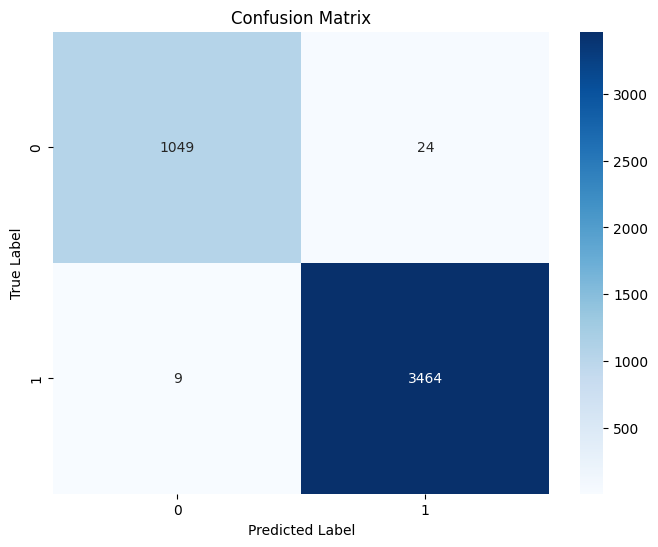

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ***CNN***

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Flatten, Dense, Dropout

In [ ]:
df = pd.read_csv("FakeNewsNetCleaned.csv")

X = df['title'].values
y = df['real'].values

In [ ]:
vocab_size = 20000
max_length = 300

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

sequences = tokenizer.texts_to_sequences(X)
padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = Sequential()

model.add(Embedding(
    input_dim=vocab_size,
    output_dim=128,
    input_length=max_length
))

model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 95s 324ms/step - accuracy: 0.7866 - loss: 0.4679 - val_accuracy: 0.8363 - val_loss: 0.3851
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 91s 321ms/step - accuracy: 0.8861 - loss: 0.2835 - val_accuracy: 0.8344 - val_loss: 0.3820
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 142s 322ms/step - accuracy: 0.9450 - loss: 0.1562 - val_accuracy: 0.8275 - val_loss: 0.4898
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 92s 322ms/step - accuracy: 0.9734 - loss: 0.0779 - val_accuracy: 0.8154 - val_loss: 0.6367
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 93s 326ms/step - accuracy: 0.9822 - loss: 0.0516 - val_accuracy: 0.8073 - val_loss: 0.8113


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.8073 - loss: 0.8113
Test Accuracy: 0.8073031306266785


In [ ]:
def predict_news(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_length, padding='post')
    pred = model.predict(pad)[0][0]
    return "Fake News" if pred > 0.5 else "Real News"

In [ ]:
predict_news("Breaking news: shocking truth revealed by scientists")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


'Real News'

# ***Transfer Learning***

In [ ]:
# Install (if not installed)
!pip install transformers

# Imports
import pandas as pd
import torch
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
from google.colab import files

# =========================
# 1. Load Data
# =========================
df = pd.read_csv("FakeNewsNetCleaned.csv")


df = df.sample(2000, random_state=42)

X = df['title'].values
y = df['real'].values

# =========================
# 2. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 3. Load Tokenizer + Model
# =========================
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

# =========================
# 4. GPU Setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Using device:", device)

# =========================
# 5. Dataset Class
# =========================
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            str(self.texts[idx]),
            padding='max_length',
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# =========================
# 6. Data Loaders
# =========================
train_dataset = FakeNewsDataset(X_train, y_train)
test_dataset = FakeNewsDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

# =========================
# 7. Optimizer
# =========================
optimizer = AdamW(model.parameters(), lr=2e-5)

# =========================
# 8. Training Loop
# =========================
epochs = 2

model.train()

for epoch in range(epochs):
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# =========================
# 9. Evaluation
# =========================
model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(batch['label'].numpy())

# =========================
# 10. Accuracy
# =========================
accuracy = accuracy_score(true_labels, predictions)
print("BERT Accuracy:", accuracy)

Saving FakeNewsNetCleaned.csv to FakeNewsNetCleaned.csv


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cpu
Epoch 1, Loss: 99.3730


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(true_labels, predictions)
print("BERT Accuracy:", accuracy)

bert_acc = accuracy

In [ ]:
print("BERT ACC:", bert_acc)

# ***Model Comparision***

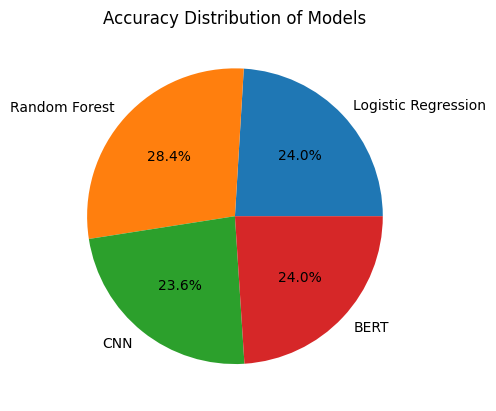

In [ ]:
import matplotlib.pyplot as plt


log_reg_acc = 0.84
rf_acc = 0.9927
cnn_acc = 0.8231
bert_acc = 0.8375

models = ['Logistic Regression', 'Random Forest', 'CNN', 'BERT']
accuracies = [log_reg_acc, rf_acc, cnn_acc, bert_acc]

plt.figure()
plt.pie(accuracies, labels=models, autopct='%1.1f%%')

plt.title("Accuracy Distribution of Models")

plt.show()

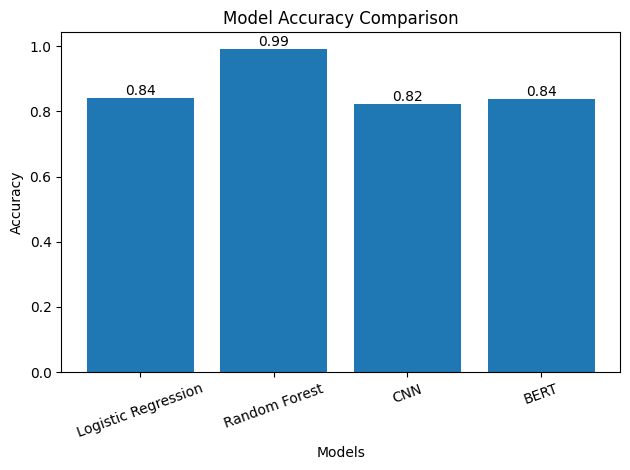

In [ ]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest', 'CNN', 'BERT']
accuracies = [log_reg_acc, rf_acc, cnn_acc, bert_acc]

plt.figure()

bars = plt.bar(models, accuracies)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}',
             ha='center', va='bottom')

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()